# 04 -- Strategy and OOS backtest

Calibrated probability -> asymmetry gate -> hysteresis state machine -> TC-aware backtest. Thresholds are tuned on **CV out-of-fold predictions**, never on the hold-out. The hold-out window (2019-2021) contains COVID.

In [1]:
%load_ext autoreload
%autoreload 2
import sys, json
sys.path.insert(0, '..')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
sns.set_theme(style='whitegrid')

In [2]:
summary = json.load(open('../artifacts/summary.json'))
summary

{'seed': 42,
 'n_train': 988,
 'n_holdout': 121,
 'n_train_pos': 214,
 'n_holdout_pos': 23,
 'holdout_start': '2019-01-01',
 'holdout_end': '2021-04-20',
 'auc_raw_holdout': 0.7369121561668146,
 'pr_auc_raw_holdout': 0.3562259645337033,
 'backtest_metrics': {'ann_return': 0.1332246395904526,
  'ann_vol': 0.11033595425692362,
  'sharpe': 1.1348771635667585,
  'sortino': 1.0744303078277575,
  'max_drawdown': -0.16940077540064813,
  'calmar': 0.7864464567848896,
  'bench_ann_return': 0.2747654035492706,
  'bench_ann_vol': 0.17512064729474267,
  'bench_sharpe': 1.3894975781004757,
  'bench_sortino': 1.3939898214920912,
  'bench_max_drawdown': -0.27722049916020153,
  'bench_calmar': 0.9911438886432703,
  'turnover_per_year': 2.5785123966942147,
  'n_flips': 6.0},
 'thresholds': {'enter': 0.7, 'exit': 0.2, 'dwell': 2, 'gate_tau': 0.25}}

## Tuned thresholds and OOS metrics

These thresholds came out of `tune_thresholds(...)` over the pooled CV out-of-fold predictions, maximising net Sharpe of a synthetic backtest.

In [3]:
thr = pd.Series(summary['thresholds']); thr

enter       0.70
exit        0.20
dwell       2.00
gate_tau    0.25
dtype: float64

In [4]:
m = pd.Series(summary['backtest_metrics'])
core = m[['ann_return','ann_vol','sharpe','sortino','max_drawdown','calmar','turnover_per_year','n_flips']]
bench = m.filter(like='bench_')
comp = pd.concat([core.rename('strategy'), bench.rename(index=lambda s: s.replace('bench_','')).rename('bench')], axis=1)
comp

,strategy,bench
ann_return,0.133225,0.274765
ann_vol,0.110336,0.175121
sharpe,1.134877,1.389498
sortino,1.074430,1.393990
max_drawdown,-0.169401,-0.277220
calmar,0.786446,0.991144
turnover_per_year,2.578512,NaN
n_flips,6.000000,NaN


## Equity curve and drawdown (hold-out only)

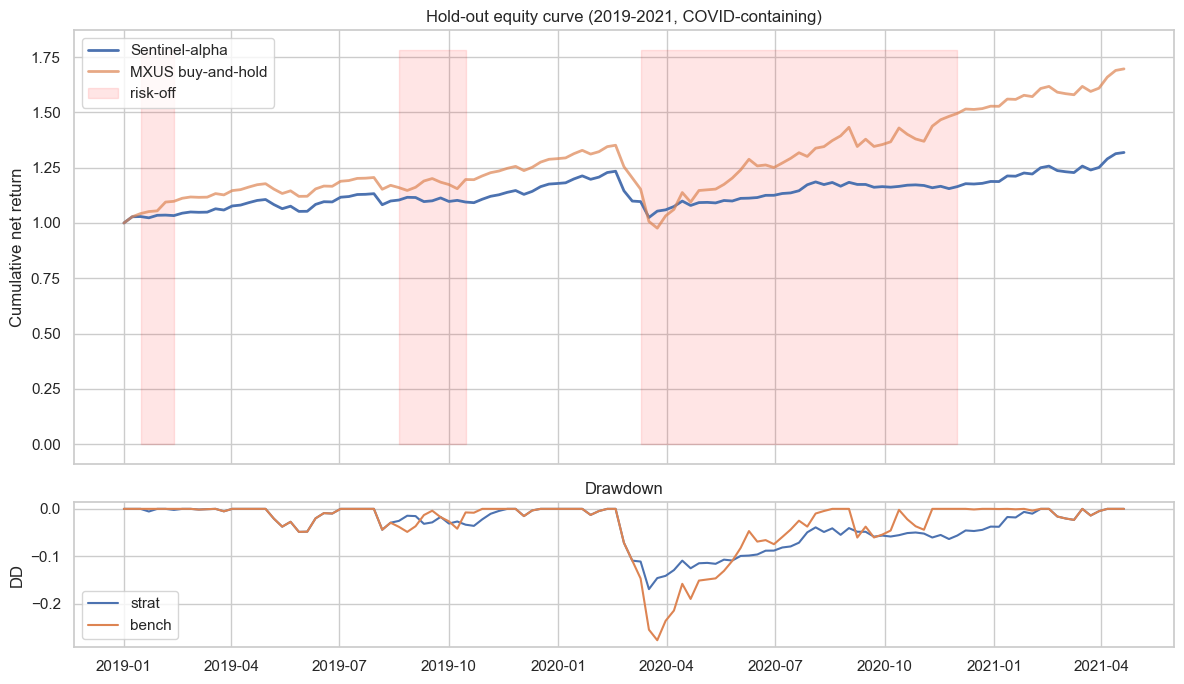

In [5]:
eq = pd.read_parquet('../artifacts/holdout_equity.parquet')
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, gridspec_kw={'height_ratios':[3,1]})
axes[0].plot(eq.index, eq['equity_strategy'], label='Sentinel-alpha', lw=2)
axes[0].plot(eq.index, eq['equity_bench'], label='MXUS buy-and-hold', lw=2, alpha=0.7)
off_periods = (eq['state_eff'] == 1)
axes[0].fill_between(eq.index, 0, eq[['equity_strategy','equity_bench']].max().max()*1.05,
    where=off_periods, color='red', alpha=0.10, label='risk-off')
axes[0].set_title('Hold-out equity curve (2019-2021, COVID-containing)')
axes[0].set_ylabel('Cumulative net return'); axes[0].legend(loc='upper left')
for col, lbl in [('equity_strategy','strat'),('equity_bench','bench')]:
    e = eq[col]; dd = e/e.cummax() - 1
    axes[1].plot(e.index, dd, label=lbl)
axes[1].set_title('Drawdown'); axes[1].set_ylabel('DD'); axes[1].legend()
plt.tight_layout(); plt.show()

## Crisis breakdown (COVID hold-out)

In [6]:
crisis = pd.read_parquet('../artifacts/holdout_crisis.parquet'); crisis

,crisis,weeks,off_weeks,off_rate,strategy_ret,bench_ret,strategy_max_dd,bench_max_dd
0,COVID,48,39,0.8125,-0.008146,0.165086,-0.169401,-0.27722


## Signal vs MXUS

Top panel: calibrated risk-off probability (after gating) vs the realised Y label. Bottom: MXUS price, shaded where the strategy was in risk-off.

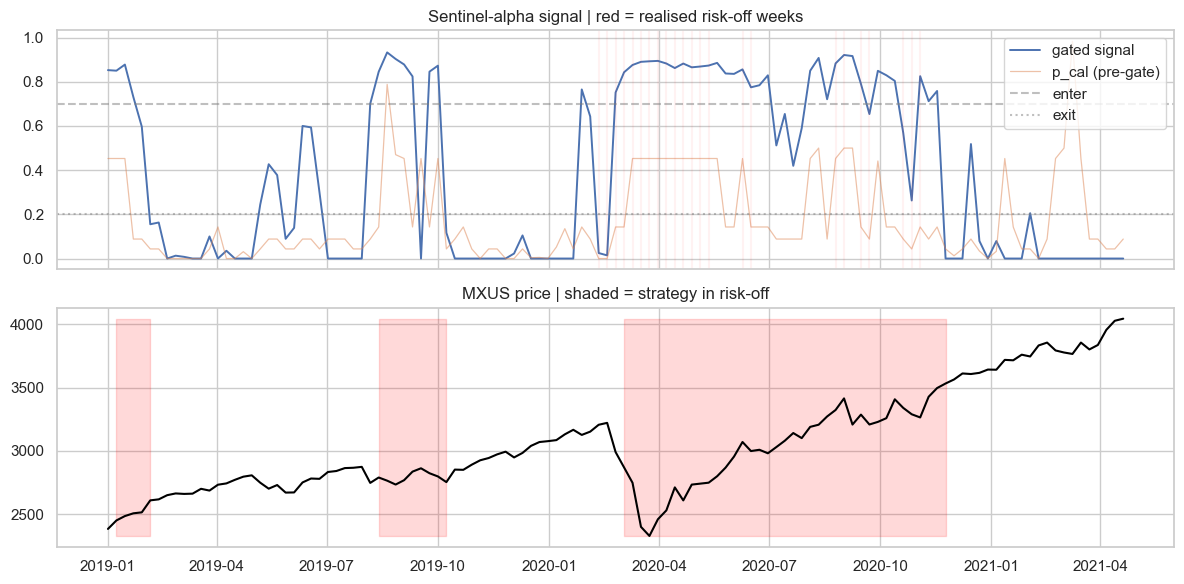

In [7]:
prob = pd.read_parquet('../artifacts/holdout_probabilities.parquet')
from sentinel_alpha.data.loader import load_dataset
d = load_dataset()
px = d.X['MXUS'].loc[prob.index]
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(prob.index, prob['signal'], lw=1.4, label='gated signal')
axes[0].plot(prob.index, prob['p_cal'], lw=0.9, alpha=0.5, label='p_cal (pre-gate)')
ytrue = prob['y']==1
for t in prob.index[ytrue]:
    axes[0].axvline(t, color='red', alpha=0.05)
axes[0].axhline(summary['thresholds']['enter'], color='gray', ls='--', alpha=0.5, label='enter')
axes[0].axhline(summary['thresholds']['exit'], color='gray', ls=':', alpha=0.5, label='exit')
axes[0].set_title('Sentinel-alpha signal | red = realised risk-off weeks')
ax2=axes[0]; ax2.legend()
axes[1].plot(px.index, px.values, color='black')
axes[1].fill_between(prob.index, px.min(), px.max(), where=(prob['state']==1), color='red', alpha=0.15)
axes[1].set_title('MXUS price | shaded = strategy in risk-off')
plt.tight_layout(); plt.show()